# Ex 7: Customer Segmentation using Clustering

**Student Roll Number:** [Enter Roll Number]

---

## SCENARIO 1 – GROUP CUSTOMERS USING K-MEANS CLUSTERING
**Problem Statement:** Group customers into clusters based on similarity using K-Means clustering.  
**Dataset:** Mall Customer Segmentation Dataset  
**Target Variable:** Cluster labels (unsupervised)  
**Input Features:** Annual Income, Spending Score  

### 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## 2. Load Dataset
Using the Mall Customer Segmentation dataset.

In [2]:
# Load the dataset
# Update the path if necessary depending on where the notebook is run from
try:
    df = pd.read_csv('Mall_Customers.csv')
except FileNotFoundError:
    df = pd.read_csv('ex_7/Mall_Customers.csv')

print(df.head())
print(df.info())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


## 3. Data Preprocessing & Feature Selection
- Check for missing values
- Select relevant features (Annual Income and Spending Score)
- Scale features since K-Means is a distance-based metric.

In [3]:
# Check for missing values
print("Missing values in dataset:\n", df.isnull().sum())

# Select relevant features: Annual Income (k$) and Spending Score (1-100)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Missing values in dataset:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## 4. Determine Optimal K Using Elbow Method
Calculate Inertia (Within-Cluster Sum of Squares) for different values of K to find the "elbow" point.

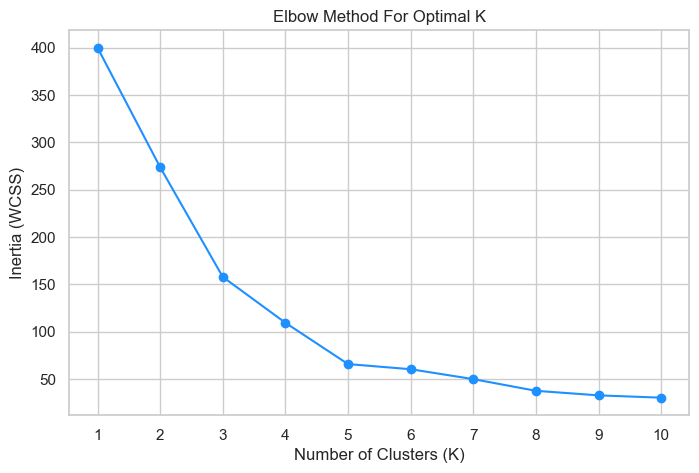

In [4]:
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='-', color='dodgerblue')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_values)
plt.show()

## 5. Apply K-Means Clustering and Evaluate
Based on the elbow plot, K=5 seems to be the optimal number of clusters. Let's fit K-Means with 5 clusters.

In [5]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels

# Evaluation Metrics
silhouette_avg = silhouette_score(X_scaled, kmeans_labels)
print(f"Optimal K: {optimal_k}")
print(f"Inertia (WCSS): {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_avg:.4f}")

Optimal K: 5
Inertia (WCSS): 65.57
Silhouette Score: 0.5547


## 6. Visualize K-Means Clusters
Visualizing the 5 distinct customer segments.

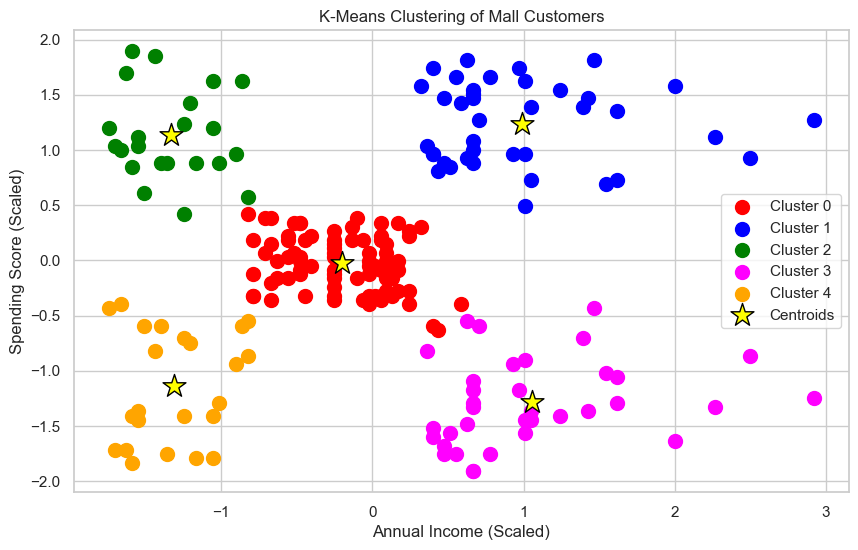

Cluster Characteristics:
- Cluster 0 (e.g., Red): High Income, Low Spending -> Careful
- Cluster 1 (e.g., Blue): Average Income, Average Spending -> Standard
- Cluster 2 (e.g., Green): High Income, High Spending -> Target
- Cluster 3 (e.g., Magenta): Low Income, High Spending -> Careless
- Cluster 4 (e.g., Orange): Low Income, Low Spending -> Sensible
(Colors might map differently based on initialization. Adjust characteristics based on actual output!)


In [6]:
plt.figure(figsize=(10, 6))

colors = ['red', 'blue', 'green', 'magenta', 'orange']
for i in range(optimal_k):
    plt.scatter(X_scaled[kmeans_labels == i, 0], X_scaled[kmeans_labels == i, 1], 
                s=100, c=colors[i], label=f'Cluster {i}')

# Plotting the centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='yellow', marker='*', edgecolor='black', label='Centroids')

plt.title('K-Means Clustering of Mall Customers')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend()
plt.show()

print("Cluster Characteristics:")
print("- Cluster 0 (e.g., Red): High Income, Low Spending -> Careful")
print("- Cluster 1 (e.g., Blue): Average Income, Average Spending -> Standard")
print("- Cluster 2 (e.g., Green): High Income, High Spending -> Target")
print("- Cluster 3 (e.g., Magenta): Low Income, High Spending -> Careless")
print("- Cluster 4 (e.g., Orange): Low Income, Low Spending -> Sensible")
print("(Colors might map differently based on initialization. Adjust characteristics based on actual output!)")

---

## SCENARIO 2 – CLUSTERING USING GMM
**Problem Statement:** Cluster data using Gaussian Mixture Models to capture probabilistic cluster membership.  
**Dataset:** Mall Customer Segmentation Dataset  
**Target Variable:** Cluster probabilities and labels  
**Input Features:** Annual Income, Spending Score  

*(Note: Data has already been loaded, preprocessed, and scaled under Scenario 1 steps. We will directly apply GMM to `X_scaled`.)*

### 3, 4, 5, 6, 7. Apply GMM, Fit Model (EM), Predict Probabilities, and Assign Clusters
GMM provides a probabilistic framework for clustering (Soft Clustering), allowing for elliptical cluster shapes and probabilistic assignments.

In [7]:
# Apply Gaussian Mixture Model
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm.fit(X_scaled)

# Predict cluster labels (hard clustering based on max probability)
gmm_labels = gmm.predict(X_scaled)
df['GMM_Cluster'] = gmm_labels

# Predict cluster probabilities (soft clustering)
probs = gmm.predict_proba(X_scaled)

# Store maximum probability for each data point
df['Cluster_Probability'] = probs.max(axis=1)

print("First few rows showing GMM Soft vs Hard Assignments:")
print(df[['Annual Income (k$)', 'Spending Score (1-100)', 'GMM_Cluster', 'Cluster_Probability']].head())

First few rows showing GMM Soft vs Hard Assignments:
   Annual Income (k$)  Spending Score (1-100)  GMM_Cluster  \
0                  15                      39            4   
1                  15                      81            2   
2                  16                       6            4   
3                  16                      77            2   
4                  17                      40            4   

   Cluster_Probability  
0             0.999032  
1             0.999790  
2             0.999814  
3             0.999694  
4             0.998378  


### 8. Evaluate GMM and Compare with K-Means using Log-Likelihood, AIC, BIC and Silhouette Score
Using statistical measures (AIC & BIC) to determine the best model complexity, computing the Log-Likelihood for our GMM model, and calculating Silhouette Score to compare hard vs soft clustering flexibility.

Log-Likelihood: -452.5005
AIC: 963.0010
BIC: 1058.6523
GMM Silhouette Score: 0.5537


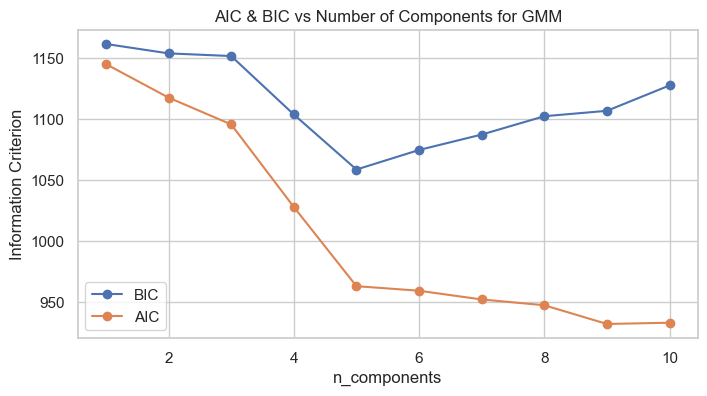

In [8]:
# Calculate log-likelihood
log_likelihood = gmm.score(X_scaled) * len(X_scaled)
print(f"Log-Likelihood: {log_likelihood:.4f}")

# AIC and BIC
print(f"AIC: {gmm.aic(X_scaled):.4f}")
print(f"BIC: {gmm.bic(X_scaled):.4f}")

gmm_silhouette = silhouette_score(X_scaled, gmm_labels)
print(f"GMM Silhouette Score: {gmm_silhouette:.4f}")

# Searching for best number of components based on AIC and BIC
n_components = np.arange(1, 11)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_scaled) for n in n_components]

plt.figure(figsize=(8, 4))
plt.plot(n_components, [m.bic(X_scaled) for m in models], label='BIC', marker='o')
plt.plot(n_components, [m.aic(X_scaled) for m in models], label='AIC', marker='o')
plt.legend(loc='best')
plt.xlabel('n_components')
plt.ylabel('Information Criterion')
plt.title('AIC & BIC vs Number of Components for GMM')
plt.show()

## 9. Visualize GMM Clusters and Compare with K-Means
Plotting the soft probability boundaries of GMM vs hard boundaries of K-Means. GMM can handle different elliptical distributions and probabilities. We visually compare spherical bounds vs elliptical overlapping boundaries.

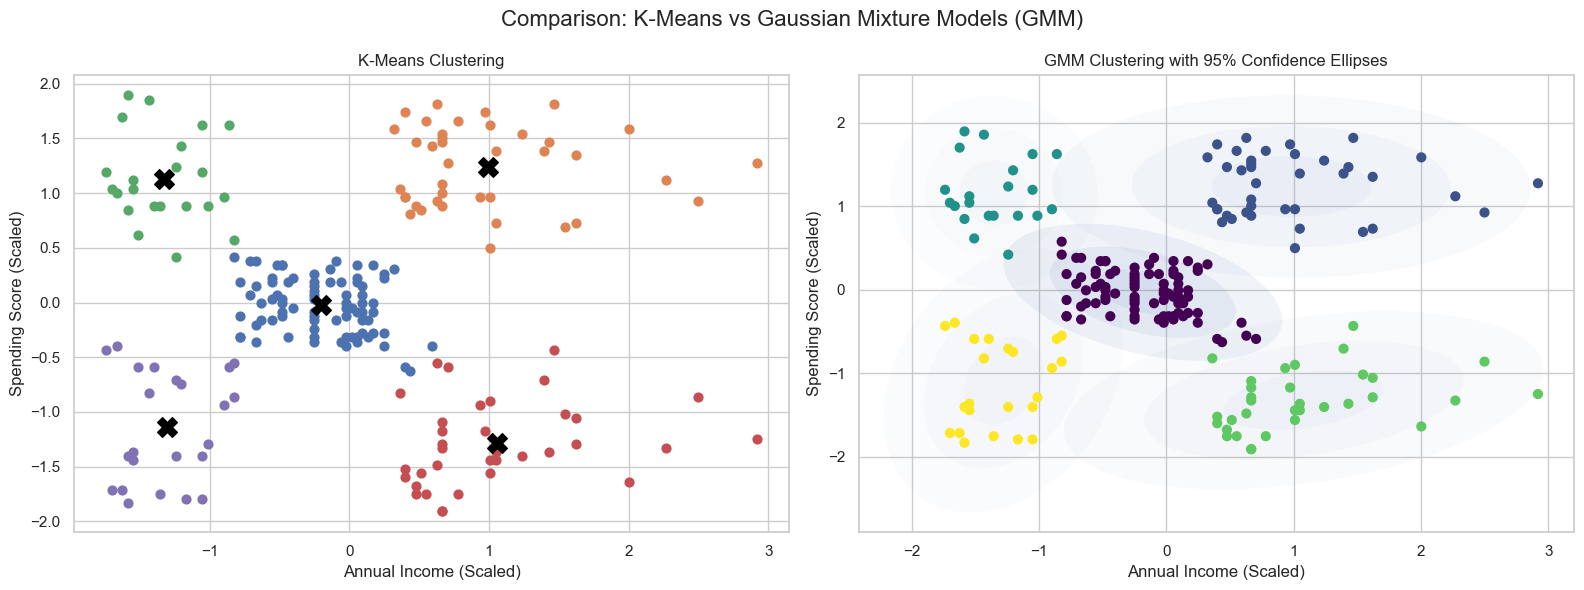


--- Summary ---
1. K-Means forms 'hard' spherical clusters based entirely on distance from centroid.
2. GMM performs 'soft' probabilistic clustering, finding both location, shape, size (variance), and orientation (covariance).
3. GMM allows capturing clusters that are overlapping or elliptical, which can be useful when features have different scales or patterns.


In [9]:
from matplotlib.patches import Ellipse

def draw_ellipse(position, covariance, ax=None, **kwargs):
    """Draw an ellipse with a given position and covariance"""
    ax = ax or plt.gca()
    
    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)
        
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(xy=position, width=nsig * width, height=nsig * height, angle=angle, **kwargs))

plt.figure(figsize=(16, 6))

# Plot K-Means Results
plt.subplot(1, 2, 1)
for i in range(optimal_k):
    plt.scatter(X_scaled[kmeans_labels == i, 0], X_scaled[kmeans_labels == i, 1], s=40, label=f'Cluster {i}')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')

# Plot GMM Results with density ellipses
plt.subplot(1, 2, 2)
ax = plt.gca()
scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=gmm_labels, s=40, cmap='viridis', zorder=2)
for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
    draw_ellipse(pos, covar, alpha=w * 0.2)

plt.title('GMM Clustering with 95% Confidence Ellipses')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')

plt.suptitle("Comparison: K-Means vs Gaussian Mixture Models (GMM)", fontsize=16)
plt.tight_layout()
plt.show()

print("\n--- Summary ---")
print("1. K-Means forms 'hard' spherical clusters based entirely on distance from centroid.")
print("2. GMM performs 'soft' probabilistic clustering, finding both location, shape, size (variance), and orientation (covariance).")
print("3. GMM allows capturing clusters that are overlapping or elliptical, which can be useful when features have different scales or patterns.")